# Omniscape examples

From <https://docs.circuitscape.org/Omniscape.jl/stable/examples>

## Forest connectivity in central Maryland

### Install packages

In [1]:
using Pkg; Pkg.add(["Omniscape", "Rasters", "Plots"])
using Omniscape, Rasters, Plots

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [8e850b90] ↑ libblastrampoline_jll v5.13.1+1 ⇒ v5.15.0+0
Precompiling packages...
    841.2 ms  ✓ DataValueInterfaces
    891.8 ms  ✓ StatsAPI
    896.7 ms  ✓ ConcreteStructs
    900.7 ms  ✓ Contour
    942.7 ms  ✓ GeoFormatTypes
    950.2 ms  ✓ IteratorInterfaceExtensions
   1089.6 ms  ✓ LaTeXStrings
   1136.3 ms  ✓ InverseFunctions
   1132.4 ms  ✓ WinReg
   1217.5 ms  ✓ Measures
   1422.4 ms  ✓ DocStringExtensions
   1514.6 ms  ✓ ADTypes
   1715.6 ms  ✓ FunctionWrappers
    871.0 ms  ✓ SimpleBufferStream
   1902.0 ms  ✓ Grisu
   1008.9 ms  ✓ InvertedIndices
   1073.3 ms  ✓ Extents
   1117.6 ms  ✓ IntervalSets
    931.2 ms  ✓ ExprTools
   2030.1 ms  ✓ OffsetArrays
   1096.0 ms  ✓ FieldMetadata
    933.4 ms  ✓ UnPack
   1346.6 ms  ✓ URIs
    857

### Download landcover data

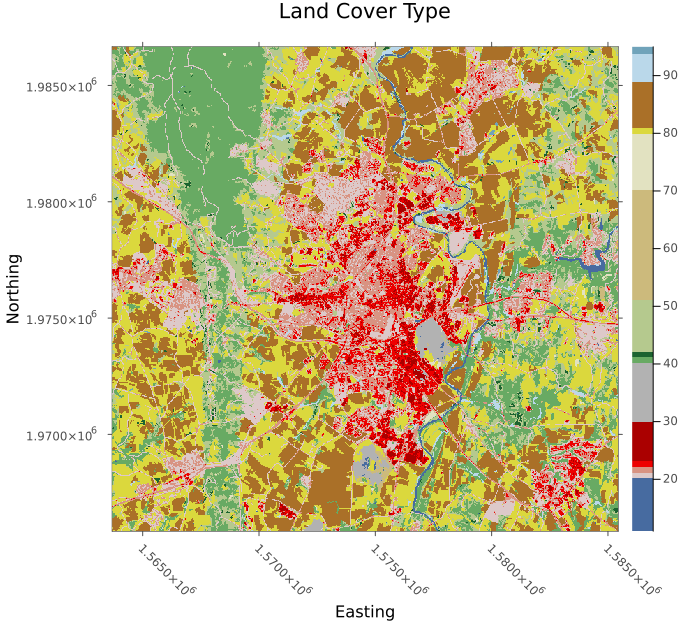

In [2]:
url_base = "https://raw.githubusercontent.com/Circuitscape/datasets/main/"
# Download the NLCD tile used to create the resistance surface and load it
download(string(url_base, "data/nlcd_2016_frederick_md.tif"),
         "nlcd_2016_frederick_md.tif")

# Plot the landcover data
values = [11, 21, 22, 23, 24, 31, 41, 42, 43, 52, 71, 81, 82, 90, 95]
palette = ["#476BA0", "#DDC9C9", "#D89382", "#ED0000", "#AA0000",
           "#b2b2b2", "#68AA63", "#1C6330", "#B5C98E", "#CCBA7C",
           "#E2E2C1", "#DBD83D", "#AA7028", "#BAD8EA", "#70A3BA"]

plot(Raster("nlcd_2016_frederick_md.tif"),
     title = "Land Cover Type", xlabel = "Easting", ylabel = "Northing",
     seriescolor = cgrad(palette, (values .- 12) ./ 84, categorical = true),
     size = (700, 640))

In [3]:
land_cover, wkt, transform = Omniscape.read_raster("nlcd_2016_frederick_md.tif", Float64)

(Union{Missing, Float64}[82.0 82.0 … 43.0 43.0; 82.0 82.0 … 43.0 43.0; … ; 82.0 81.0 … 82.0 82.0; 81.0 81.0 … 22.0 82.0], "PROJCS[\"Albers_Conical_Equal_Area\",GEOGCS[\"WGS 84\",DATUM[\"WGS_1984\",SPHEROID[\"WGS 84\",6378137,298.257223563,AUTHORITY[\"EPSG\",\"7030\"]],AUTHORITY[\"EPSG\",\"6326\"]],PRIMEM[\"Greenwich\",0],UNIT[\"degree\",0.0174532925199433,AUTHORITY[\"EPSG\",\"9122\"]],AUTHORITY[\"EPSG\",\"4326\"]],PROJECTION[\"Albers_Conic_Equal_Area\"],PARAMETER[\"latitude_of_center\",0],PARAMETER[\"longitude_of_center\",0],PARAMETER[\"standard_parallel_1\",29.5],PARAMETER[\"standard_parallel_2\",45.5],PARAMETER[\"false_easting\",0],PARAMETER[\"false_northing\",0],UNIT[\"metre\",1,AUTHORITY[\"EPSG\",\"9001\"]],AXIS[\"Easting\",EAST],AXIS[\"Northing\",NORTH]]", [1.56369e6, 30.0, 0.0, 1.98666e6, 0.0, -30.0])

In [4]:
# Create the reclassification table used to translate land cover into resistance
reclass_table = [
    11	100; # Water
    21	500; # Developed, open space
    22	1000; # Developed, low intensity
    23	missing; # Developed, medium intensity
    24	missing; # Developed, high intensity
    31	100; # Barren land
    41	1; # Deciduous forest
    42	1; # Evergreen forest
    43	1; # Mixed forest
    52	20; # Shrub/scrub
    71	30; # Grassland/herbaceous
    81	200; # Pasture/hay
    82	300; # Cultivated crops
    90	20; # Woody wetlands
    95	30; # Emergent herbaceous wetlands
]

15×2 Matrix{Union{Missing, Int64}}:
 11   100
 21   500
 22  1000
 23      missing
 24      missing
 31   100
 41     1
 42     1
 43     1
 52    20
 71    30
 81   200
 82   300
 90    20
 95    30

In [5]:
# Specify the configuration options
proj_name = "md_nlcd_omniscape_output"
config = Dict{String, String}(
    "radius" => "100",
    "block_size" => "21",
    "project_name" => proj_name,
    "source_from_resistance" => "true",
    "r_cutoff" => "1", # Only forest pixels should be sources
    "reclassify_resistance" => "true",
    "calc_normalized_current" => "true",
    "calc_flow_potential" => "true"
)

Dict{String, String} with 8 entries:
  "calc_normalized_current" => "true"
  "calc_flow_potential"     => "true"
  "radius"                  => "100"
  "source_from_resistance"  => "true"
  "block_size"              => "21"
  "r_cutoff"                => "1"
  "project_name"            => "md_nlcd_omniscape_output"
  "reclassify_resistance"   => "true"

### Run omniscape

In [6]:
if isdir(proj_name)
    rm(proj_name, recursive = true)
end

currmap, flow_pot, norm_current = run_omniscape(config,
                                                land_cover,
                                                reclass_table = reclass_table,
                                                wkt = wkt,
                                                geotransform = transform,
                                                write_outputs = true)

┌ Info: Starting up Omniscape with 4 workers and double precision
└ @ Omniscape /home/achubaty/.julia/packages/Omniscape/VSLPS/src/main.jl:215
┌ Info: Using Circuitscape with the cg+amg solver...
└ @ Omniscape /home/achubaty/.julia/packages/Omniscape/VSLPS/src/main.jl:216
┌ Info: Calculating block artifact correction array...
└ @ Omniscape /home/achubaty/.julia/packages/Omniscape/VSLPS/src/main.jl:251


MethodError: MethodError: no method matching missingarray_to_array(::Matrix{Union{Missing, Float64}}, ::Int64)
This error has been manually thrown, explicitly, so the method may exist but be intentionally marked as unimplemented.

Closest candidates are:
  missingarray_to_array(::Array{Union{Missing, T}, N} where {N, T<:Number}, ::Number)
   @ Omniscape ~/.julia/packages/Omniscape/VSLPS/src/utils.jl:614


### Cumulative current map

In [39]:
current = Raster("md_nlcd_omniscape_output/cum_currmap.tif")
plot(current,
     title = "Cumulative Current Flow", xlabel = "Easting", ylabel = "Northing",
     seriescolor = cgrad(:inferno, [0, 0.005, 0.03, 0.06, 0.09, 0.14]),
     size = (600, 550))

ArgumentError: ArgumentError: file "md_nlcd_omniscape_output/cum_currmap.tif" not found

### Flow potential

In [40]:
fp = Raster("md_nlcd_omniscape_output/flow_potential.tif")
plot(fp,
     title = "Flow Potential", xlabel = "Easting", ylabel = "Northing",
     seriescolor = cgrad(:inferno, [0, 0.005, 0.03, 0.06, 0.09, 0.14]),
     size = (700, 640))

ArgumentError: ArgumentError: file "md_nlcd_omniscape_output/flow_potential.tif" not found

### Normalized current flow

In [41]:
normalized_current = Raster("md_nlcd_omniscape_output/normalized_cum_currmap.tif")
plot(normalized_current,
     title = "Normalized Current Flow", xlabel = "Easting", ylabel = "Northing",
     seriescolor = cgrad(:inferno, [0, 0.005, 0.03, 0.06, 0.09, 0.14]),
     size = (700, 640))

ArgumentError: ArgumentError: file "md_nlcd_omniscape_output/normalized_cum_currmap.tif" not found